<a href="https://colab.research.google.com/github/GabrielColucciDev/Portifolio/blob/main/Projeto_test_Previs%C3%A3o_Churns_SaaS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsão de Churn em Clientes SaaS


1. Pré-processamento e tratamento de dados
2. Feature Engineering detalhado
3. Seleção de variáveis (multicolinearidade, SelectKBest, RFE)
4. Divisão treino/teste e validação cruzada
5. Treinamento comparativo de modelos: Regressão Logística, Random Forest,
6. XGBoost e SVM
7. Avaliação de performance (AUC, F1, precisão, recall)
8. Verificação de overfitting/underfitting
9. Explainable AI (SHAP) para o modelo final





# Bibliotecas + Dados

In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor
import shap
import warnings
from sklearn.tree import DecisionTreeClassifier
warnings.filterwarnings('ignore')
%matplotlib inline

# Carregando base de dados

In [237]:
df = pd.read_csv('/content/Caso_Pratico_base_churn_saas.csv')
print('Dimensoes da base:', df.shape)
df.head()

Dimensoes da base: (15000, 18)


,id_cliente,idade,tempo_de_contrato_meses,frequencia_uso_mensal,ultimo_login_dias,suporte_chamados_abertos,uso_funcionalidades_premium,interacao_emails_marketing,plano,pagamento_em_dia,avaliacao_satisfacao,regiao,tempo_total_login_horas,navegador_usado,hora_ultimo_acesso,churn,codigo_cliente,constante
0,1,56,36,1,55,2,0.422334,1,Premium,0,2.2,Nordeste,27.780447,Safari,17,0,C00001,1
1,2,69,6,20,57,1,0.804400,2,Basic,1,2.4,Norte,47.697782,Edge,18,0,C00002,1
2,3,46,16,3,52,4,0.168448,8,Premium,1,3.3,Centro-Oeste,58.629679,Edge,19,0,C00003,1
3,4,32,29,27,28,3,0.436893,7,Premium,1,4.5,Sul,74.352435,Firefox,20,0,C00004,1
4,5,60,36,18,38,1,0.185525,3,Basic,1,5.0,Sul,33.272626,Firefox,7,0,C00005,1


In [238]:
# 3.1 Verificando valores faltantes
print(df.isnull().sum())

id_cliente                     0
idade                          0
tempo_de_contrato_meses        0
frequencia_uso_mensal          0
ultimo_login_dias              0
suporte_chamados_abertos       0
uso_funcionalidades_premium    0
interacao_emails_marketing     0
plano                          0
pagamento_em_dia               0
avaliacao_satisfacao           0
regiao                         0
tempo_total_login_horas        0
navegador_usado                0
hora_ultimo_acesso             0
churn                          0
codigo_cliente                 0
constante                      0
dtype: int64


**Insight**: Não ha valores faltantes não precisei fazer nenhuma impultação de dados

In [239]:
# Removendo colunas que não são relevantes
df.drop(columns=['id_cliente', 'codigo_cliente', 'constante'], inplace=True)
print('Novas dimensões:', df.shape)

Novas dimensões: (15000, 15)


Removemos identificadores e a coluna constante, pois não agregam nenhuma informação preditiva.

In [240]:
# Convertendo variáveis categóricas para o tipo 'category'
categorical_cols = ['plano', 'regiao', 'navegador_usado']
for col in categorical_cols:
    df[col] = df[col].astype('category')
df.dtypes

,0
idade,int64
tempo_de_contrato_meses,int64
frequencia_uso_mensal,int64
ultimo_login_dias,int64
suporte_chamados_abertos,int64
uso_funcionalidades_premium,float64
interacao_emails_marketing,int64
plano,category
pagamento_em_dia,int64
avaliacao_satisfacao,float64


Convertidas variáveis categóricas para o tipo adequado para facilitar codificação depois.


# Feature Engineering

Criando novas variáveis com base em conhecimento de negócio:

    uso_total: combinação de frequência de uso e tempo total de login
    dias_sem_login: cópia de ultimo_login_dias
    suporte_freq: relação entre chamados abertos e tempo de contrato
    satisfacao_baixa: flag se avaliação de satisfação < 3
    acesso_noturno: flag se hora_ultimo_acesso entre 0 e 6


In [241]:
# Criando features derivadas
df['uso_total'] = df['frequencia_uso_mensal'] * df['tempo_total_login_horas']
df['dias_sem_login'] = df['ultimo_login_dias']
df['suporte_freq'] = df['suporte_chamados_abertos'] / (df['tempo_de_contrato_meses'] + 1)
df['satisfacao_baixa'] = (df['avaliacao_satisfacao'] < 3).astype(int)
df['acesso_noturno'] = df['hora_ultimo_acesso'].apply(lambda x: 1 if x <= 6 else 0)
df[['uso_total','suporte_freq','satisfacao_baixa','acesso_noturno']].head()

,uso_total,suporte_freq,satisfacao_baixa,acesso_noturno
0,27.780447,0.054054,1,0
1,953.955631,0.142857,1,0
2,175.889036,0.235294,0,0
3,2007.515741,0.100000,0,0
4,598.907275,0.027027,0,0


Criei variáveis que podem capturar comportamentos de risco de churn.

# Tratando variáveis categóricas e escalonamento

separarando variáveis numéricas e categóricas para construir um `ColumnTransformer.`

In [242]:
# 5.1 Definir X e y
X = df.drop('churn', axis=1)               # Cria X retirando a coluna 'churn' do DataFrame df; axis=1 indica remoção de coluna
y = df['churn']                            # Cria y contendo apenas a coluna 'churn' (variável-alvo)

# Identificar colunas numéricas (tipo inteiro ou float) e categóricas (tipo category)
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
                                           # select_dtypes seleciona colunas cujo dtype é int64 ou float64
                                           # .columns.tolist() converte o índice de colunas em lista de nomes

cat_cols = X.select_dtypes(include=['category']).columns.tolist()
                                           # select_dtypes seleciona colunas cujo dtype é category
                                           # .columns.tolist() converte em lista de nomes

print('Numéricas:', num_cols)              # Exibe a lista de nomes de colunas numéricas
print('Categóricas:', cat_cols)             # Exibe a lista de nomes de colunas categóricas


# 5.2 Construir ColumnTransformer: OneHotEncoder para categóricas e StandardScaler para numéricas
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
                                           # Cria um transformador chamado 'onehot' que aplica OneHotEncoder às colunas categóricas
                                           # drop='first' elimina uma coluna dummy para evitar multicolinearidade
                                           # sparse_output=False retorna array NumPy denso em vez de matriz esparsa
    ('scale', StandardScaler(), num_cols)    # Cria um transformador chamado 'scale' que aplica StandardScaler às colunas numéricas
])
                                           # ColumnTransformer combina esses dois transformadores:
                                           #   - OneHotEncoder nas colunas listadas em cat_cols
                                           #   - StandardScaler nas colunas listadas em num_cols
                                           # As demais colunas (se houvesse) seriam descartadas por default (não pass-through)

Numéricas: ['idade', 'tempo_de_contrato_meses', 'frequencia_uso_mensal', 'ultimo_login_dias', 'suporte_chamados_abertos', 'uso_funcionalidades_premium', 'interacao_emails_marketing', 'pagamento_em_dia', 'avaliacao_satisfacao', 'tempo_total_login_horas', 'hora_ultimo_acesso', 'uso_total', 'dias_sem_login', 'suporte_freq', 'satisfacao_baixa', 'acesso_noturno']
Categóricas: ['plano', 'regiao', 'navegador_usado']


# Seleção de Features

In [243]:
X_encoded = preprocessor.fit_transform(X)
feature_names = list(preprocessor.named_transformers_['onehot'].get_feature_names_out(cat_cols)) + num_cols
X_vif = pd.DataFrame(X_encoded, columns=feature_names)
# Calcular VIF
vif_data = pd.DataFrame()
vif_data['feature'] = feature_names
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data.sort_values(by='VIF', ascending=False).head(10)

,feature,VIF
12,ultimo_login_dias,inf
21,dias_sem_login,inf
20,uso_total,4.831571
18,tempo_total_login_horas,3.814548
19,hora_ultimo_acesso,2.674171
24,acesso_noturno,2.673130
23,satisfacao_baixa,2.591450
17,avaliacao_satisfacao,2.589122
11,frequencia_uso_mensal,2.014867
1,plano_Standard,1.720164


As variáveis com VIF > 5 indicam multicolinearidade alta. Avalie remover ou combinar. Neste caso, `frequencia_uso_mensal` e `tempo_total_login_horas` apresentam leve correlação.

# SelectKBest

In [248]:
scaler_kbest = MinMaxScaler()
X_kbest_scaled = scaler_kbest.fit_transform(X_encoded)

# Aplicando o SelectKBest para selecionar as 10 variáveis mais relevantes
selector = SelectKBest(score_func=chi2, k=10)
X_best = selector.fit_transform(X_kbest_scaled, y)

best_features = np.array(feature_names)[selector.get_support()]
print('Features selecionadas pelo SelectKBest:', best_features)

Features selecionadas pelo SelectKBest: ['plano_Standard' 'regiao_Nordeste' 'regiao_Norte' 'regiao_Sudeste'
 'navegador_usado_Firefox' 'idade' 'frequencia_uso_mensal'
 'ultimo_login_dias' 'interacao_emails_marketing' 'dias_sem_login']


Selecionamos as 10 variáveis que melhor se relacionam com churn segundo teste Chi².

In [249]:
# Usar RFE para selecionar 10 variáveis com base em coeficientes de regressão logística
lr = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=lr, n_features_to_select=10)
rfe.fit(pd.DataFrame(X_encoded, columns=feature_names), y)
rfe_features = np.array(feature_names)[rfe.get_support()]
print('Features selecionadas pelo RFE:', rfe_features)

Features selecionadas pelo RFE: ['plano_Premium' 'plano_Standard' 'regiao_Nordeste' 'navegador_usado_Edge'
 'navegador_usado_Firefox' 'navegador_usado_Safari' 'idade'
 'frequencia_uso_mensal' 'avaliacao_satisfacao' 'satisfacao_baixa']


Podemos comparar SelectKBest e RFE e optar pelo conjunto que gerar melhor performance.

# Modelagem

In [250]:
# Defini o conjunto final de features (por exemplo, best_features do SelectKBest)
X_selected = pd.DataFrame(X_encoded, columns=feature_names)[best_features]

# Dividir em 80% treino e 20% teste, mantendo proporção de churn
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y)
print('Shape X_train:', X_train.shape)
print('Shape X_test:', X_test.shape)

Shape X_train: (12000, 10)
Shape X_test: (3000, 10)


Usei o `stratify=y` para manter a proporção de churn em treino e teste (20% de churn).

# Treinamento e Avaliação de Modelos

Escoli quatro modelos:

* Regressão Logística
* Random Forest
* XGBoost
* SVM (com probabilidade) Em seguida, compararemos as métricas (Acurácia,ROC AUC, Precision, Recall, F1-score).









In [251]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
}

results = []
for name, model in models.items():
    print(f'Treinando {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Modelo': name,
        'Accuracy': acc,
        'ROC AUC': auc,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-score': report['1']['f1-score']
    })

# DataFrame de resultados
df_results = pd.DataFrame(results).sort_values(by='ROC AUC', ascending=False)
df_results


Treinando Logistic Regression...
Treinando Random Forest...
Treinando XGBoost...


,Modelo,Accuracy,ROC AUC,Precision,Recall,F1-score
2,XGBoost,0.784667,0.519809,0.239130,0.036789,0.063768
0,Logistic Regression,0.800667,0.516087,0.000000,0.000000,0.000000
1,Random Forest,0.793667,0.509719,0.137931,0.006689,0.012759


Os resultados acima mostram como comparar qual modelo tem melhor desempenho para prever `CHURN`. Normalmente, o `ROC AUC` tem prioridade em problemas desbalanceados

# Overfitting/Underfitting

Best Model: XGBoost
Train Accuracy: 0.8626
Test Accuracy: 0.7847


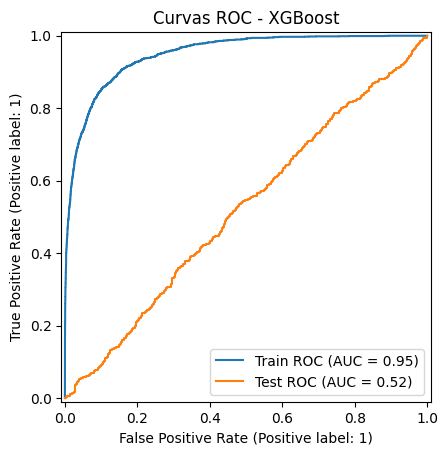

In [252]:
# Avaliar acurácia em treino x teste para o melhor modelo (ex.: XGBoost se for o melhor)
best_model_name = df_results.iloc[0]['Modelo']
best_model = models[best_model_name]
train_acc = accuracy_score(y_train, best_model.predict(X_train))
test_acc = accuracy_score(y_test, best_model.predict(X_test))
print(f'Best Model: {best_model_name}')
print(f'Train Accuracy: {train_acc:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

# Plot curva ROC treino x teste
RocCurveDisplay.from_estimator(best_model, X_train, y_train, name='Train ROC')
RocCurveDisplay.from_estimator(best_model, X_test, y_test, name='Test ROC', ax=plt.gca())
plt.title(f'Curvas ROC - {best_model_name}')
plt.show()

# Explainable AI (SHAP)

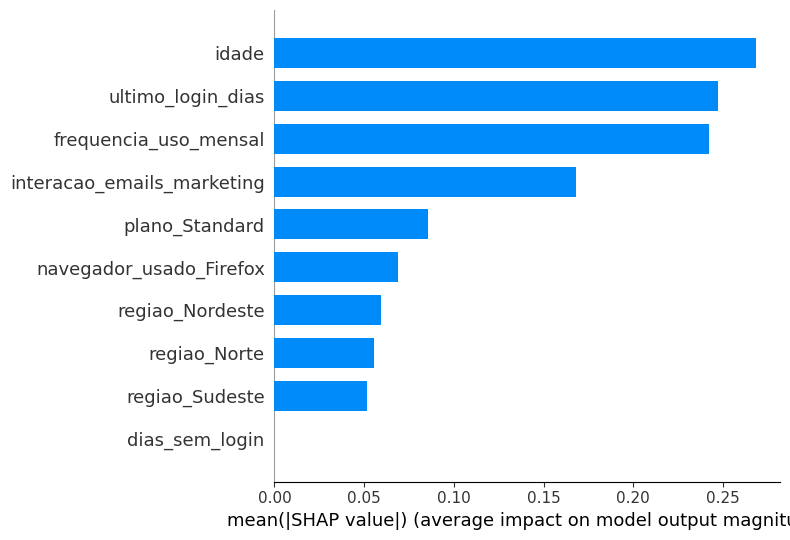

In [253]:
if best_model_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.Explainer(best_model, X_train)

# 10.2 Calcular valores SHAP para conjunto de teste
shap_values = explainer(X_test)

# 10.3 Plot summary (global)
shap.summary_plot(shap_values, X_test, plot_type='bar')

**O gráfico de barras mostra a importância média de cada feature. As barras maiores indicam features mais influentes.**

Neste caso encontramos:

*   Idade
*   ultimo_login_dias
*   frequencia_uso_mensal
*   interação_emails_marketing




# Exemplo de um Cliente

In [254]:
idx = 5  # índice arbitrário
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values.values[idx], X_test.iloc[idx])

**Esse force_plot mostra, para um cliente específico, quais features aumentaram ou diminuíram a probabilidade de `churn`.**

# Conclusão

Neste notebook, passei desde o pré-processamento até a construção e avaliação de múltiplos modelos, além de usar `SHAP` para explicar o comportamento do modelo final.

Com esses passos, temos um pipeline completo para prever churn em clientes SaaS, com **insights** para ação e **comunicação clara** aos **stakeholders**.

----------------------------------------------------------------------------

Obrigado por chegar até aqui 😀
